# Calidad de datos: nulos, duplicados y outliers

## Introduccion

Esta es una continuacion del notebook ``1.0--initial_data_exploration.ipynb`` en donde ya se pudo observar algunos puntos claves del dataset como:

- El dataset no presenta valores nulos NA ni valores nulos disfrazados como valores con 0 que no tengan sentido
- El dataset no presenta valores duplicados, al usar la libreria **ydata-profiling** pudimos observar esto.

Lo que se buscara entonces hacer en este notebook es el analisis de outliers ya que vimos presencia de estos en el target **salary**


### Librerias e importacion del dataset

In [ ]:
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [11]:
ruta = pathlib.Path(r"E:\ROAD_TO_DATA_SCIENCE\proyectos_programacion\python\SALARYLENS\SalaryLens-Predictor-de-Retorno-Laboral-con-Machine-Learning\data\raw\job_salary_prediction_dataset.csv")

match ruta.exists():
    case True:
        print("Dataset encontrado correctamente en la ruta, leyendo datos...")
        df = pd.read_csv(ruta)
        display(df.head(10))
    case False:
        print("Dataset no encontrado en la ruta establecida.")

Dataset encontrado correctamente en la ruta, leyendo datos...


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
5,AI Engineer,0,High School,4,Education,Enterprise,USA,No,2,180351
6,Backend Developer,6,High School,16,Manufacturing,Enterprise,Canada,No,3,165375
7,Machine Learning Engineer,4,Bachelor,18,Healthcare,Enterprise,Canada,Hybrid,5,202463
8,AI Engineer,5,Diploma,14,Telecom,Enterprise,Singapore,Yes,0,171834
9,Frontend Developer,18,PhD,2,Retail,Enterprise,India,Hybrid,5,128377


### 2. Analisis de outliers

#### 2.1. Limites y numero de outliers

In [25]:
tipos = df.dtypes

# Listas vacias para almacenar las features numericas
num_cols = []
# Lista vacia para almacenar las features de texto
tex_cols = []

# Recorremos las columnas y almacenamos cada una de los nombres de las columas en sus respectivas listas
for key, value in tipos.items():
    if value == "int64":
        num_cols.append(key)
    else:
        tex_cols.append(key)

print(num_cols)


['experience_years', 'skills_count', 'certifications', 'salary']


In [81]:
outliers_limites = []


# Calculamos el IQR de las columnas numericas

for key in num_cols:
    
    # calculo de iqr
    q1, q3 = np.percentile(df[key], [25,75])
    iqr = q3-q1 # Rango intercuartil

    # calculamos el rango de decision (fuera de este cualquier valor se considerara outlier)
    
    limite_inf = q1 - 1.5 * iqr
    if limite_inf < 0:
        limite_inf = 0
    limite_sup = q3 + 1.5 * iqr

    # Contamos el numero de outliers
    # Valores demasiado bajos
    outliers_bajos = (df[key] < limite_inf).sum()

    # Valores demasiado altos (si tienes un limite_sup)
    outliers_altos = (df[key] > limite_sup).sum()

    # Almacenamos los valores en un diccionario

    outliers_limites.append(
        {
            "feature" : key,
            "iqr" : iqr,
            "limite_inferior" : limite_inf,
            "limite_superior" : limite_sup,
            "outliers_bajos" : outliers_bajos,
            "outliers_altos" : outliers_altos
        }
    )

# Almacenamos la lista de diccionarios en formato DataFrame de pandas
pd.DataFrame(outliers_limites)


,feature,iqr,limite_inferior,limite_superior,outliers_bajos,outliers_altos
0,experience_years,10.0,0.0,30.0,0,0
1,skills_count,10.0,0.0,30.0,0,0
2,certifications,3.0,0.0,8.5,0,0
3,salary,50134.0,44157.0,244693.0,26,2310


Puede causar problemas el que los valores de limites inferiores esten en negativo, asi que se pondra como limite el 0, en realidad el que aparezcan en valores negativos es porque el calculo matematico lo hace asi, pero sabemos que en este caso el limite de los valores inferiores en cualquiera de los casos es 0

#### 2.2. Visualizacion de outliers usando Boxplots

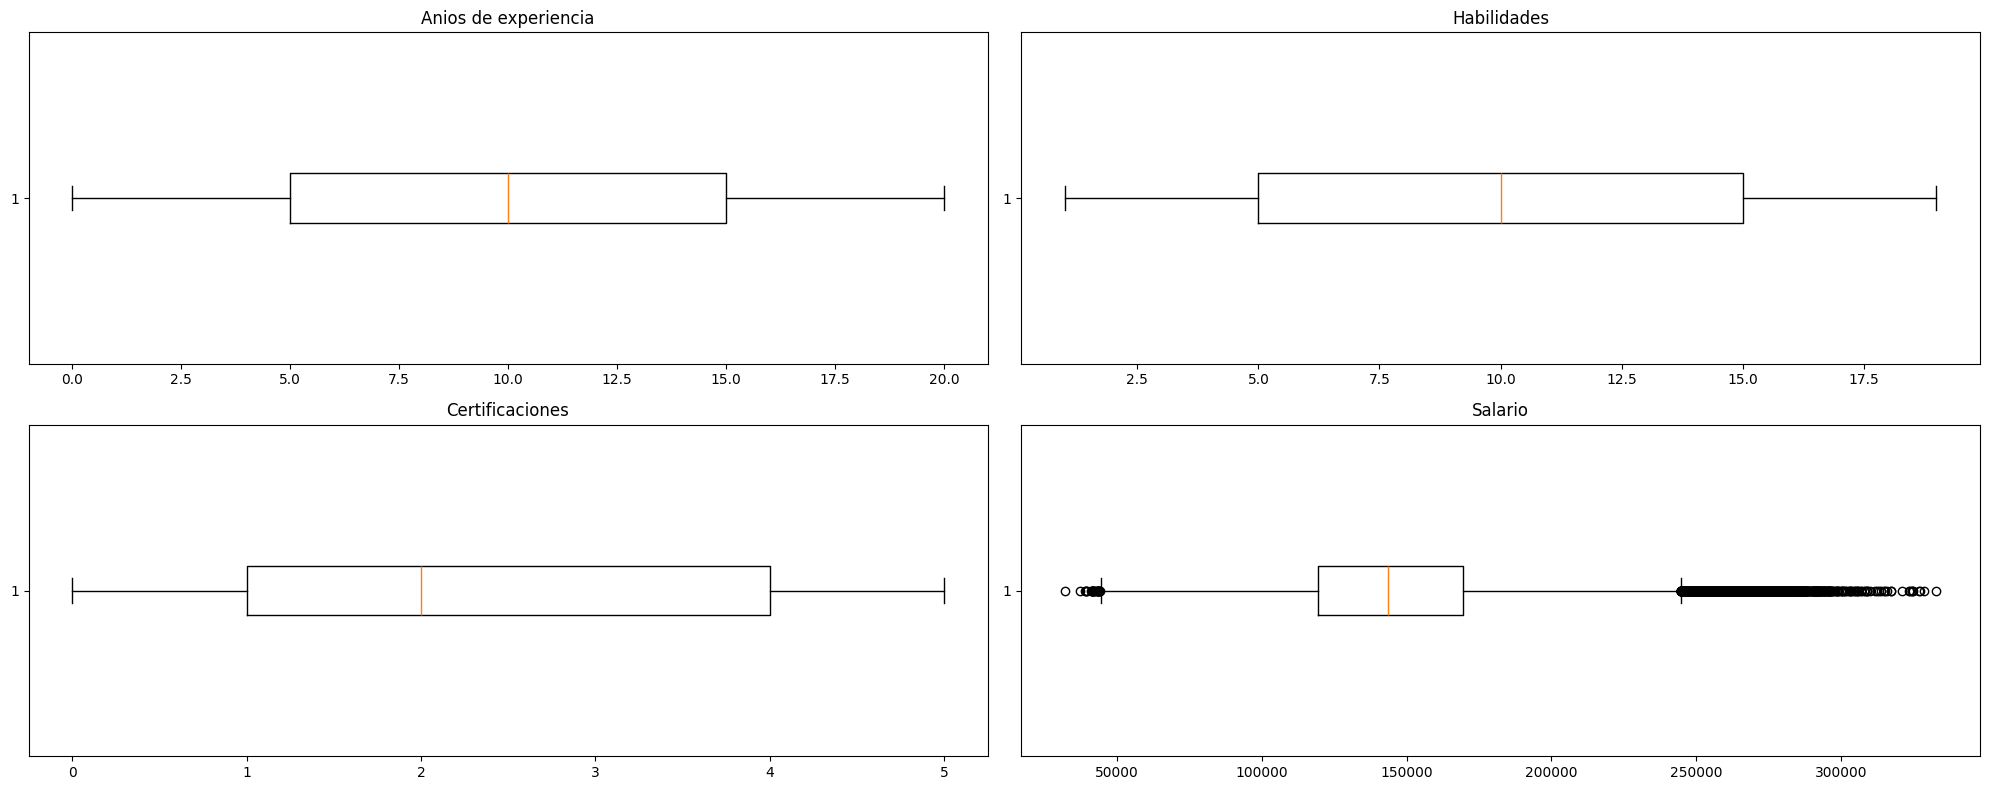

In [100]:
fig, ax = plt.subplots(2,2, figsize=(20,8))

# Feature: anios de experiencia
ax[0, 0].boxplot(df["experience_years"], vert=False)
ax[0, 0].set_title("Anios de experiencia")

# Feature: numero de habilidades
ax[0, 1].boxplot(df["skills_count"], vert=False)
ax[0, 1].set_title("Habilidades")
# Feature: numero de certificaciones
ax[1, 0].boxplot(df["certifications"], vert=False)
ax[1, 0].set_title("Certificaciones")
# Feature: salary
ax[1, 1].boxplot(df["salary"], vert=False)
ax[1, 1].set_title("Salario")

plt.tight_layout() # Evita que se solapen los títulos
plt.show()


#### Decision fundamentada

Los outliers que observamos en salary provienen casi en su mayoria de valores mayores al limite superior de 244693.0 dolares y algunos pocos de menores al limite inferior obtenidos despues de hacer el calculo del iqr y el rango de decision, Tenemos ahora varias opciones, una de ellas es eliminar los datos, pero esto haria que cuando ya apliquemos modelos de machine learning los modelos no puedan predecir correctamente valores altos de salario, lo cual es sumamente importante para nosotros, asi que, la decision que se tomara sera transformar esos datos atipicos (outliers), se utilizara una transformacion logaritmica para mitigar el sesgo en el modelo sin perder la representatividad de los perfiles de alta remuneracion

#### Pipeline limpieza

In [2]:
from sklearn import preprocessing